In [71]:
import pandas as pd

In [72]:
import numpy as np

# load and explore the data

In [73]:
data = pd.read_csv("Customer Churn.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [74]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [75]:
print(data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [77]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [78]:
duplicates = data.duplicated().sum()
print(f"number of duplicated rows: {duplicates}")

number of duplicated rows: 0


# pre processing the data

In [79]:
categorical_cols = data.select_dtypes(include=['object']).columns
print("categorical columns:\n",categorical_cols)

categorical columns:
 Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [80]:
data.drop("customerID",axis = 1, inplace = True)

In [81]:
data["Churn"] = data["Churn"].map({"No":0, "Yes":1})

In [82]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors = 'coerce')

In [83]:
data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace = True)

In [84]:
from sklearn.preprocessing import StandardScaler

In [85]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [86]:
data = pd.get_dummies(data,drop_first = True)

# exploratory data analysis(EDA)

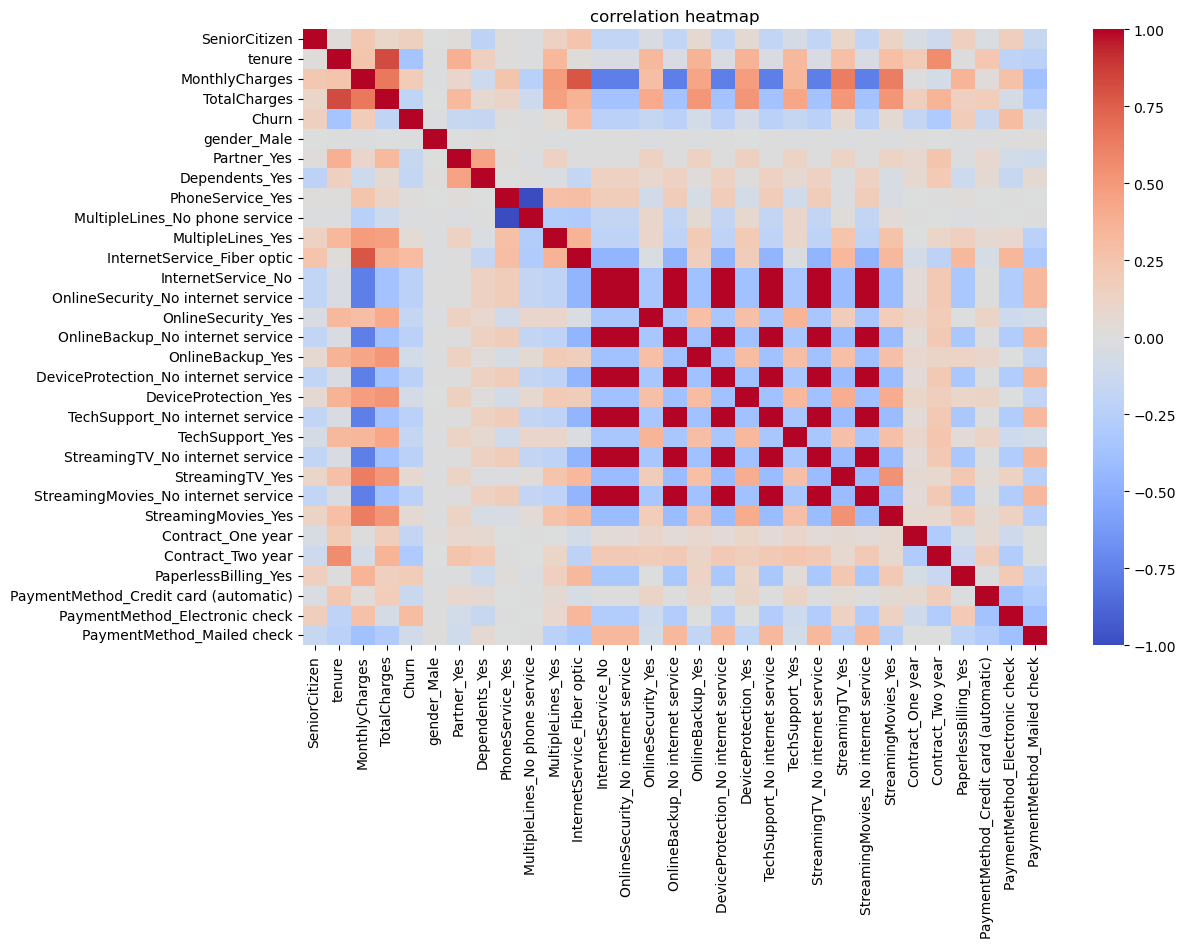

In [87]:
# correlation heat map
import matplotlib.pyplot as plt

import seaborn as sns

corr_matrix = data.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap = 'coolwarm', center=0, annot=False)
plt.title("correlation heatmap")
plt.show()

In [88]:
churn_corr = corr_matrix["Churn"].sort_values(ascending = False)
print(churn_corr.head(10))

Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
PhoneService_Yes                  0.011942
Name: Churn, dtype: float64


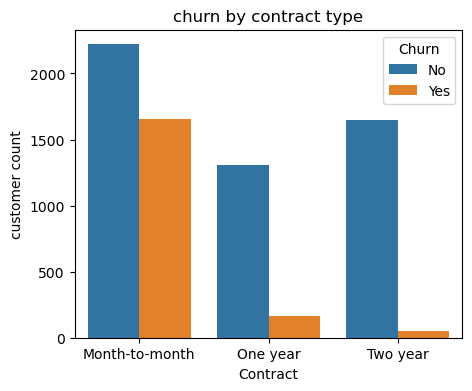

In [89]:
raw_data = pd.read_csv("Customer Churn.csv")

# churn by contract type

plt.figure(figsize=(5,4))
sns.countplot(x='Contract', hue = 'Churn', data=raw_data)
plt.title('churn by contract type')
plt.ylabel('customer count')
plt.show()

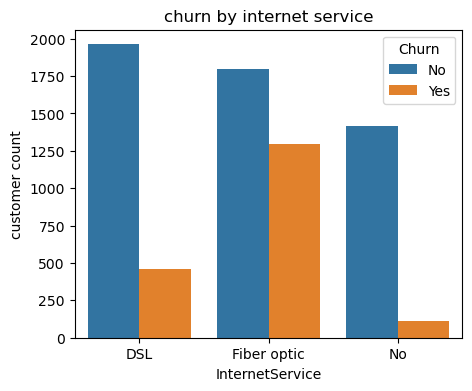

In [90]:
#churn by internet service

plt.figure(figsize=(5,4))
sns.countplot(x = 'InternetService', hue = 'Churn', data =raw_data)
plt.title("churn by internet service")
plt.ylabel("customer count")
plt.show()

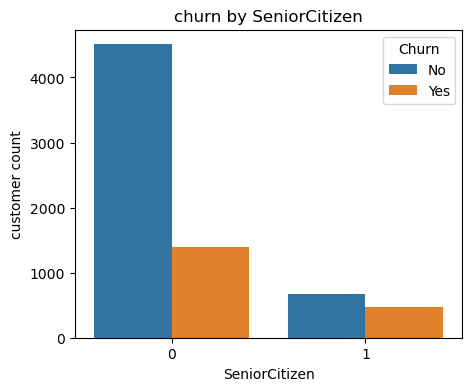

In [91]:
# churn by SeniorCitizen

plt.figure(figsize=(5,4))
sns.countplot(x= 'SeniorCitizen', hue='Churn', data = raw_data)
plt.title("churn by SeniorCitizen")
plt.ylabel("customer count")
plt.show()

# hypothesis testing(t-test).

In [92]:
from scipy import stats
import numpy as np

alpha = 0.05
grp1 = data.loc[data["Churn"] == 1, "MonthlyCharges"]
grp0 = data.loc[data["Churn"] == 0, "MonthlyCharges"]

print(stats.shapiro(grp1.sample(500) if len(grp1) > 500 else grp1))
print(stats.shapiro(grp0.sample(500) if len(grp0) > 500 else grp0))

print(stats.levene(grp1, grp0))

tstat, pval = stats.ttest_ind(grp1, grp0, equal_var = False)
print("t =", tstat, "p =", pval)

ShapiroResult(statistic=0.919404149055481, pvalue=1.072974327253175e-15)
ShapiroResult(statistic=0.9085116982460022, pvalue=8.805062334919122e-17)
LeveneResult(statistic=361.8444859598826, pvalue=1.0261244899425954e-78)
t = 18.407526676414676 p = 8.59244933154656e-73


# statistical modeling

In [93]:
import statsmodels.api as sm
import pandas as pd

y = data["Churn"]

X = data.drop("Churn", axis=1)

X= sm.add_constant(X)

In [94]:
X = X.astype(float)

In [95]:
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.413838
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7019
Method:                           MLE   Df Model:                           23
Date:                Sat, 06 Dec 2025   Pseudo R-squ.:                  0.2848
Time:                        17:18:19   Log-Likelihood:                -2914.7
converged:                       True   LL-Null:                       -4075.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -1.7133   7.4

# machine learning

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [61]:
X = data.drop("Churn",axis=1)
y = data["Churn"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 43, stratify=y)

In [63]:
# RandomForestClassifier

rf_model = RandomForestClassifier(random_state = 43)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [64]:
# LogisticRegression

lg_model = LogisticRegression(max_iter=1000)
lg_model.fit(X_train, y_train)

y_pred_lg = lg_model.predict(X_test) 

In [65]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

Accuracy: 0.8097491717936584
Precision: 0.6870588235294117
Recall: 0.5204991087344029


In [66]:
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf))


Classification report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1552
           1       0.69      0.52      0.59       561

    accuracy                           0.81      2113
   macro avg       0.76      0.72      0.73      2113
weighted avg       0.80      0.81      0.80      2113



In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

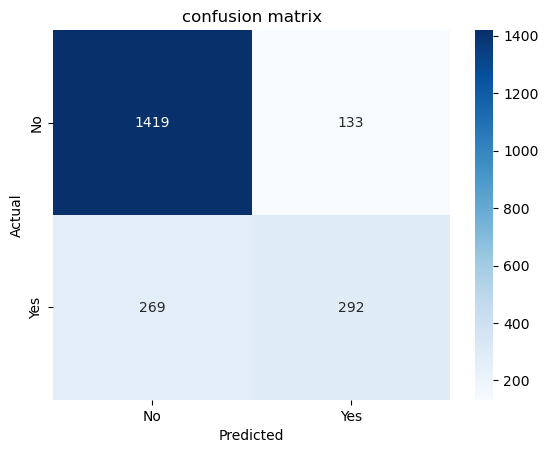

In [68]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No","Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion matrix")
plt.show()